# I. Sprint 1 - Préparation des données 

##### Livrable 1 - Groupe 4 : AIT RAZOUK Ilyass, IZEM Mohammed Amine, BOIVIN Pierre, WYART Nathan

## Contexte

Le diabète fait partie des maladies chroniques les plus courantes aux États-Unis et touche chaque année des millions de personnes. Cette affection sérieuse se traduit par une mauvaise régulation du sucre dans le sang, ce qui peut, à long terme, réduire la qualité de vie et même l’espérance de vie. Au moment de la digestion, les aliments se transforment en sucres qui passent dans le sang. Cela incite le pancréas à produire de l’insuline, une hormone qui permet aux cellules d’utiliser ces sucres comme source d’énergie. Dans le cas du diabète, soit l’organisme ne produit pas assez d’insuline, soit il réagit mal.

L’excès prolongé de sucre dans le sang augmente les risques de complications graves : maladies cardiovasculaires, perte de la vue, amputations ou encore insuffisance rénale. Même si le diabète ne se guérit pas, il est possible d’en limiter les effets grâce à la perte de poids, à une alimentation adaptée, à une activité physique régulière et à un suivi médical approprié. Plus le diagnostic est posé tôt, plus il est possible d’agir efficacement. C’est pour cette raison que les outils de prédiction du risque de diabète représentent un enjeu important de santé publique.

L’ampleur du phénomène est frappante. Selon les Centres pour le contrôle et la prévention des maladies (CDC) en 2018, 34,2 millions d’Américains vivaient avec un diabète, et 88 millions étaient prédiabétiques. Une personne diabétique sur cinq n’en avait pas conscience, et la grande majorité des personnes prédiabétiques ignorait également leur situation. Le diabète de type 2, la forme la plus fréquente, est influencé par de nombreux facteurs : âge, niveau d’études, revenus, zone géographique, origine ethnique ou encore conditions sociales de vie. Les populations les plus défavorisées sont souvent les plus touchées.

La maladie représente aussi un poids financier immense : le coût du diabète diagnostiqué est estimé à environ 327 milliards de dollars par an, et si l’on inclut le diabète non diagnostiqué et le prédiabète, on approche les 400 milliards de dollars.

## Présentation du jeu de données

Le Système de surveillance des facteurs de risque comportementaux (BRFSS) est une enquête téléphonique annuelle menée par les Centres pour le contrôle et la prévention des maladies (CDC) sur la santé. Chaque année, cette enquête recueille les réponses de plus de 400 000 Américains sur leurs comportements à risque pour la santé, leurs maladies chroniques et leur recours aux services de prévention. Elle est réalisée chaque année depuis 1984. Pour ce projet, nous avons utilisé un fichier CSV des données disponibles sur Kaggle pour l'année 2015. Ce jeu de données contient les réponses de 253 680 personnes et comporte 22 variables. Ces variables correspondent soit à des questions posées directement aux participants, soit à des variables calculées à partir de leurs réponses individuelles.

Les variables du dataset sont :

- Diabetes_binary(0 = no diabetes 1 = prediabetes  2 = diabetes)

- HighBP(0 = no high BP 1 = high BP)

- HighChol(0 = no high cholesterol 1 = high cholesterol)

- CholCheck(0 = no cholesterol check in 5 years 1 = yes cholesterol check in 5 years)

- BMI(Body Mass Index)

- Smoker(Have you smoked at least 100 cigarettes in your entire life? [Note: 5 packs = 100 cigarettes] 0 = no 1 = yes)

- Stroke((Ever told) you had a stroke. 0 = no 1 = yes)

- HeartDiseaseorAttack(coronary heart disease (CHD) or myocardial infarction (MI) 0 = no 1 = yes)

- PhysActivity(physical activity in past 30 days - not including job 0 = no 1 = yes)

- Fruits(Consume Fruit 1 or more times per day 0 = no 1 = yes)

- Veggies(Consume Vegetables 1 or more times per day 0 = no 1 = yes)

- HvyAlcoholConsump((adult men >=14 drinks per week and adult women>=7 drinks per week) 0 = no 1 = yes)

- AnyHealthcare(Have any kind of health care coverage, including health insurance, prepaid plans such as HMO, etc. 0 = no 1 = yes)

- NoDocbcCost(Was there a time in the past 12 months when you needed to see a doctor but could not because of cost? 0 = no 1 = yes)

- GenHlth(Would you say that in general your health is: scale 1-5 1 = excellent 2 = very good 3 = good 4 = fair 5 = poor)

- MentHlth(days of poor mental health scale 1-30 days)

- PhysHlth(physical illness or injury days in past 30 days scale 1-30)

- DiffWalk(Do you have serious difficulty walking or climbing stairs? 0 = no 1 = yes)

- Sex(0 = female 1 = male)

- Age(13-level age category (_AGEG5YR see codebook) 1 = 18-24 9 = 60-64 13 = 80 or older)

- Education(Education level (EDUCA see codebook) scale 1-6 1 = Never attended school or only kindergarten 2 =)

- Income(Income scale (INCOME2 see codebook) scale 1-8 1 = less than $10,000 5 = less than $35,000 8 = $75,000 or more)

## Importations des librairies

Ici, nous importons les bibliothèques nécessaires pour manipuler des données, les visualiser et préparer un modèle de machine learning.

Nous utilisons : 
- pandas et numpy : Traitement des données
- matplotlib et seaborn : Visualisation
- train_test_split : Séparer les données en ensembles d’entraînement et de test
- StandardScaler : Normaliser les variables

In [19]:
# Bibliothèques standards et utilitaires
import time
import joblib

# Manipulation de données et mathématiques
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning & Évaluation (Scikit-Learn, Imblearn, CodeCarbon)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from codecarbon import EmissionsTracker

# Deep Learning (TensorFlow / Keras)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Enregistrement et suivi des expériences (MLflow)
import mlflow
import mlflow.keras

## Chargement du Dataset et Typage des variables

Ici, nous chargeons notre Dataset (fichier .csv) contenant les données dans un DataFrame df à l’aide de pandas.

Ensuite, nous affichons les premières lignes du dataset avec df.head() afin de visualiser rapidement sa structure et vérifier que les données ont bien été importées.

## Analyse et typage des variables

Nous utilisons df.shape pour obtenir les dimensions du DataFrame df.

Cela nous permet de connaître le nombre de lignes et de colonnes du dataset.

Nous utilisons aussi df.info() pour afficher un résumé du DataFrame df.

Cela nous donne des informations sur les colonnes (noms, types de données), le nombre de valeurs non nulles et l’utilisation mémoire, ce qui permet de mieux comprendre la structure et vérifier la qualité des données.

df.describe() nous permet d'obtenir des statistiques descriptives du DataFrame df.

Cela nous donne un résumé des variables numériques : moyenne, écart-type, valeurs minimales et maximales, ainsi que les quartiles (25%, 50%, 75%), afin de mieux comprendre la distribution des données.

## Nettoyage des données

#### Gestion des valeurs nulls

Ici, nous utilisons df.isnull().sum() pour vérifier les valeurs manquantes dans le DataFrame df.

Cette commande compte le nombre de valeurs nulles pour chaque colonne, ce qui nous permet d’identifier rapidement si des données sont manquantes et dans quelles variables.

#### Gestion des valeurs dupliquées

Ici, nous utilisons df.duplicated().sum() pour détecter les lignes dupliquées dans le DataFrame df.

Cette commande compte le nombre de lignes identiques présentes plusieurs fois, ce qui nous permet d’identifier d’éventuels doublons à nettoyer dans les données.

In [20]:
df = pd.read_csv("diabetes_binary_health_indicators_BRFSS2015.csv")

In [21]:
df.duplicated().sum()

np.int64(24206)

Comme il existe des lignes dupliquées, nous les supprimons du DataFrame df à l’aide de df.drop_duplicates().

Cela permet de nettoyer les données en ne conservant qu’une seule occurrence de chaque ligne identique.

In [22]:
df = df.drop_duplicates()

## Séparation de la variable cible et des variables explicatives

Nous séparons les données en variables explicatives et en variable cible.

- X contient toutes les colonnes sauf "Diabetes_binary", qui servent de features (entrées du modèle).
- y contient la colonne "Diabetes_binary", qui est la cible que nous cherchons à prédire.

In [23]:
X = df.drop("Diabetes_binary", axis=1)
y = df["Diabetes_binary"]

## Analyse Exploratoire qualitative / quantitative

Ici, nous affichons les distributions des variables du DataFrame df sous forme d’histogrammes avec df.hist().

Le paramètre figsize=(15,12) permet de définir la taille globale des graphiques, et plt.show() sert à afficher les figures. Cela nous aide à visualiser la distribution de chaque variable.

Nous avons choisi de supprimer les variables CholCheck, Stroke, HvyAlcoholConsump et AnyHealthcare car elles présentent une variance quasi nulle (les clients ont presque tous la même réponse).

Un modèle d'apprentissage a besoin de contrastes et de différences pour réussir à séparer les profils sains des profils malades. Puisque ces 4 colonnes ne permettent pas de distinguer les clients entre eux, elles n'apportent aucun pouvoir prédictif. Les supprimer permet d'éliminer du bruit et d'alléger les calculs du réseau de neurones.

In [24]:
cols_to_drop = ['CholCheck', 'Stroke', 'HvyAlcoholConsump', 'AnyHealthcare']
df = df.drop(columns=cols_to_drop)

Nous standardisons certaines colonnes du DataFrame df.

Nous sélectionnons les colonnes 'BMI', 'MentHlth' et 'PhysHlth'. Nous appliquons StandardScaler pour les mettre à la même échelle (moyenne 0 et variance 1). Enfin, nous remplaçons les anciennes valeurs par les valeurs standardisées dans le DataFrame.

In [25]:
cols = ['BMI', 'MentHlth', 'PhysHlth']

scaler = StandardScaler()
df[cols] = scaler.fit_transform(df[cols])

print(df)

        Diabetes_binary  HighBP  HighChol       BMI  Smoker  \
0                   0.0     1.0       1.0  1.666251     1.0   
1                   0.0     0.0       0.0 -0.543144     1.0   
2                   0.0     1.0       1.0 -0.101265     0.0   
3                   0.0     1.0       0.0 -0.248558     0.0   
4                   0.0     1.0       1.0 -0.690437     0.0   
...                 ...     ...       ...       ...     ...   
253675              0.0     1.0       1.0  2.402716     0.0   
253676              1.0     1.0       1.0 -1.574195     0.0   
253677              0.0     0.0       0.0 -0.101265     0.0   
253678              0.0     1.0       0.0 -0.837730     0.0   
253679              1.0     1.0       1.0 -0.543144     0.0   

        HeartDiseaseorAttack  PhysActivity  Fruits  Veggies  NoDocbcCost  \
0                        0.0           0.0     0.0      1.0          0.0   
1                        0.0           1.0     0.0      0.0          1.0   
2              

Nous affichons les histogrammes des colonnes 'BMI', 'MentHlth' et 'PhysHlth' du DataFrame df.

Le paramètre figsize=(15, 5) ajuste la taille des graphiques pour mieux les visualiser côte à côte, et plt.show() permet d’afficher les histogrammes.

Nous analysons les corrélations entre les variables du dataset pour identifier les meilleurs prédicteurs et supprimer les doublons :
1. On calcule d’abord la matrice de corrélation avec df.corr().
2. Ensuite, on affiche une heatmap avec seaborn pour visualiser les relations entre toutes les colonnes. L'objectif est d'identifier la colinéarité : si deux variables explicatives sont trop corrélées entre elles, on en supprime une pour alléger le modèle et éviter le bruit.
3. Puis, on isole les corrélations avec la variable cible "Diabetes_binary" et nous les trions.
4. Enfin, on représente ces corrélations sous forme de barplot pour identifier les variables les plus fortement liées à la cible. Ce seront les indices les plus importants pour notre réseau de neurones.

Ici, nous extrayons les corrélations entre chaque variable et la cible "Diabetes_binary" à partir de la matrice de corrélation.

Nous les trions ensuite par ordre décroissant avec sort_values(ascending=False) afin d’identifier les variables les plus fortement corrélées à la cible.

Ici, nous affichons des boîtes à moustaches (boxplots) pour toutes les variables du DataFrame df.

Cela nous permet de visualiser la distribution des données, ainsi que les valeurs aberrantes (outliers). Le figsize ajuste la taille du graphique, xticks(rotation=90) permet de mieux lire les noms des variables, et plt.show() affiche le tout.

Nous affichons un boxplot pour comparer la distribution du BMI en fonction de la variable "Diabetes_binary".

Cela nous permet d’observer comment le BMI varie selon les personnes diabétiques ou non, et de repérer d’éventuelles différences de distribution entre les deux groupes.

Nous affichons un countplot pour visualiser la distribution de la variable "Diabetes_binary".

Cela nous permet de voir le nombre d’observations dans chaque classe (diabétique vs non diabétique) et d’identifier un éventuel déséquilibre entre les classes.

## Scission Train / Test / Validation

Ici, nous divisons les données en ensembles d’entraînement et temporaire.

Nous utilisons train_test_split pour séparer X et y :

70 % des données sont utilisées pour l’entraînement (X_train, y_train)
30 % sont mises de côté dans X_temp et y_temp pour une future séparation (validation/test)

Le paramètre random_state=42 permet de rendre la séparation reproductible.

In [26]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)

Ensuite, nous divisons l’ensemble temporaire en deux parties : validation et test.

Nous utilisons train_test_split sur X_temp et y_temp :

50 % deviennent les données de validation (X_val, y_val)
50 % deviennent les données de test (X_test, y_test)

In [27]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

Enfin, nous standardisons les variables explicatives pour mettre toutes les features sur la même échelle.

Nous créons un StandardScaler, puis nous l’ajustons et transformons les données d’entraînement avec fit_transform
nous transformons les données de validation et de test avec transform uniquement (en utilisant les paramètres appris sur le train)

Cela permet d’éviter toute fuite d’information et d’assurer une bonne généralisation du modèle.

In [28]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)

X_test_scaled = scaler.transform(X_test)

## Feature Ingineering

Pour pallier le fort déséquilibre de notre jeu de données, nous avions initialement appliqué la méthode SMOTE (Synthetic Minority Over-sampling Technique), dont le but est d'équilibrer les classes en générant des observations synthétiques pour la classe minoritaire. Cependant, cette technique a rapidement engendré un phénomène de surapprentissage, le modèle ayant tendance à mémoriser ces données artificielles plutôt qu'à généraliser. Pour corriger ce biais sans sacrifier notre capacité de détection, nous avons remplacé SMOTE par l'utilisation de poids de classes (class_weight="balanced"). 

Contrairement à SMOTE qui modifie le jeu de données, la méthode des poids agit directement sur le calcul de l'erreur lors de l'entraînement. En attribuant mathématiquement une pénalité plus lourde à la classe minoritaire, nous forçons l'algorithme à accorder une importance capitale aux patients diabétiques : une erreur sur un vrai malade lui "coûtera" beaucoup plus cher qu'une erreur sur un patient sain. Cette approche nous a permis de maintenir une détection stricte de la maladie tout en stabilisant l'apprentissage.

In [29]:
classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, class_weights))

print(" Class weights :", class_weights)

 Class weights : {np.float64(0.0): np.float64(0.5900041872663028), np.float64(1.0): np.float64(3.2776485471759713)}


Nous affichons à nouveau les histogrammes de toutes les variables du DataFrame df avec df.hist().

Le paramètre figsize=(15,12) ajuste la taille des graphiques pour une meilleure lisibilité, et plt.show() permet de les afficher.

## Sauvegarde du Dataset nettoyé

Une fois toutes ces étapes effectuées, nous sauvegardons le DataFrame df dans un fichier CSV nommé "diabetes_clean.csv".

Le paramètre index=False permet de ne pas inclure l’index du DataFrame dans le fichier exporté, afin d’obtenir un fichier plus propre.

In [30]:
df.to_csv("diabetes_clean.csv", index=False)

## Sauvegarde des objets du Pipeline

Enfin, on sauvegarde l’objet scaler entraîné dans un fichier avec joblib.

La fonction joblib.dump() permet de sérialiser le scaler et de l’enregistrer sous le nom "scaler.pkl", afin de pouvoir le recharger et l’utiliser plus tard sans avoir à le réentraîner.

In [31]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

## Conclusion Sprint 1

Dans ce premier livrable, nous avons préparé et exploré le dataset en vue d’une future modélisation.

Nous avons commencé par charger et analyser les données (structure, statistiques, valeurs manquantes, doublons), puis nous avons effectué un nettoyage en supprimant les duplications.

Ensuite, nous avons exploré les données visuellement (histogrammes, boxplots, corrélations) afin de mieux comprendre leur distribution et leur lien avec la variable cible "Diabetes_binary".

Nous avons également réalisé un prétraitement des données en normalisant certaines variables et en séparant le dataset en ensembles d’entraînement, de validation et de test. Enfin, nous avons pris en compte le déséquilibre des classes grâce à class weights, et sauvegardé les données et le scaler pour une utilisation future.

En résumé, nous avons construit une base de données propre, analysée et prête à être utilisée pour entraîner des modèles de machine learning dans les prochains livrables.

## Sprint 2 & 3 - Développement, Comparaison et Optimisation du Modèle Deep Learning, MLOps

Dans cette seconde phase, nous abordons la conception technique de notre intelligence artificielle. L'objectif est de mettre en compétition différentes architectures de réseaux de neurones (simple, profond, régularisé) afin d'identifier la plus apte à dépister le diabète. Cette analyse comparative s'appuiera sur des indicateurs visuels précis (courbes d'apprentissage, matrices de confusion, courbes ROC) et des métriques adaptées aux exigences médicales, notamment la maximisation du taux de détection (Recall). Enfin, nous proposerons un modèle final optimisé, alliant performances de santé et efficacité énergétique grâce à l'évaluation de sa consommation de ressources.

Pour le choix du framework de deep learning, nous avons opté pour TensorFlow/Keras plutôt que PyTorch car Keras offre une API de haut niveau idéale pour le prototypage rapide sur des données tabulaires. De plus, l'écosystème TensorFlow intègre des outils natifs pour le déploiement en production (TensorFlow Serving) et le MLOps (TFX), répondant parfaitement aux exigences de notre livrable.

On peut observer que les modèles Simple et Profond sont très similaires. Ils excellent dans la détection des malades avec un excellent Recall (79 % pour le simple, 78 % pour le profond). En contrepartie, ils génèrent beaucoup de "fausses alertes" chez les patients sains, ce qui fait baisser leur exactitude globale (autour de 69-70 %).

De son côté le modèle Régularisé semble globalement meilleur au premier abord (Exactitude de 75 % et meilleur F1-score). Cependant, ce gain se fait au détriment de la détection des malades : son Recall chute à 70 %.

Dans un contexte médical de dépistage du diabète, la priorité absolue est de minimiser les Faux Négatifs (les malades renvoyés chez eux par erreur). Le modèle Simple est celui qui rattrape le plus de malades (79 % de Recall). Il est préférable d'avoir une précision faible (31 %, donc prescrire des examens de contrôle inutiles à des patients sains) plutôt que de rater près de 30 % des diabétiques comme le ferait le modèle régularisé.

Nous avons alors décidés de garder le modèle simple, cependant nous allons modifier ses paramètres afin d'améliorer sa performances et d'avoir de meilleurs résultats.

Pour transformer le modèle simple en une architecture optimisée, cinq paramètres clés ont été intégrés :

1. La profondeur (Couches à 64 et 32 neurones) : L'ajout de couches supplémentaires permet au réseau d'extraire des schémas plus complexes et subtils dans les données des patients.

2. La Normalisation par lot (Batch Normalization) : Cette technique recentre mathématiquement les informations entre chaque couche. Elle stabilise le modèle et évite que certains neurones ne saturent.

3. Le Dropout (0.3) : Il désactive aléatoirement 30 % des neurones à chaque étape de l'entraînement. Cela empêche le réseau de mémoriser les données par cœur (surapprentissage) et le force à être performant sur des données inédites.

4. Le Taux d'apprentissage (Learning Rate à 0.0005) : En diminuant la vitesse d'apprentissage de l'optimiseur Adam, on force l'algorithme à avancer à "petits pas", ce qui lui permet de trouver un réglage de précision bien plus fin.

5. Le Seuil de décision (0.3) : Externe à l'architecture mais vital pour l'évaluation médicale, il permet de classer un patient comme "Diabétique" dès 30 % de probabilité, maximisant ainsi le repêchage des malades (Recall).


ENTRAÎNEMENT DU MODÈLE OPTIMISÉ


Epoch 15: early stopping
Restoring model weights from the end of the best epoch: 8.


2026/04/14 14:07:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



BILAN ÉNERGÉTIQUE ET RAPIDITÉ :
⏱️ Temps d'entraînement total : 92.49 secondes
📉 Epochs calculées : 15 sur 80
🌱 Économie : 65 epochs inutiles évitées !
⚡ Réduction d'environ 81% de la consommation prévue.
🔌 Consommation électrique mesurée : 0.000925 kWh
🌍 Émissions de CO2 estimées : 0.052 grammes


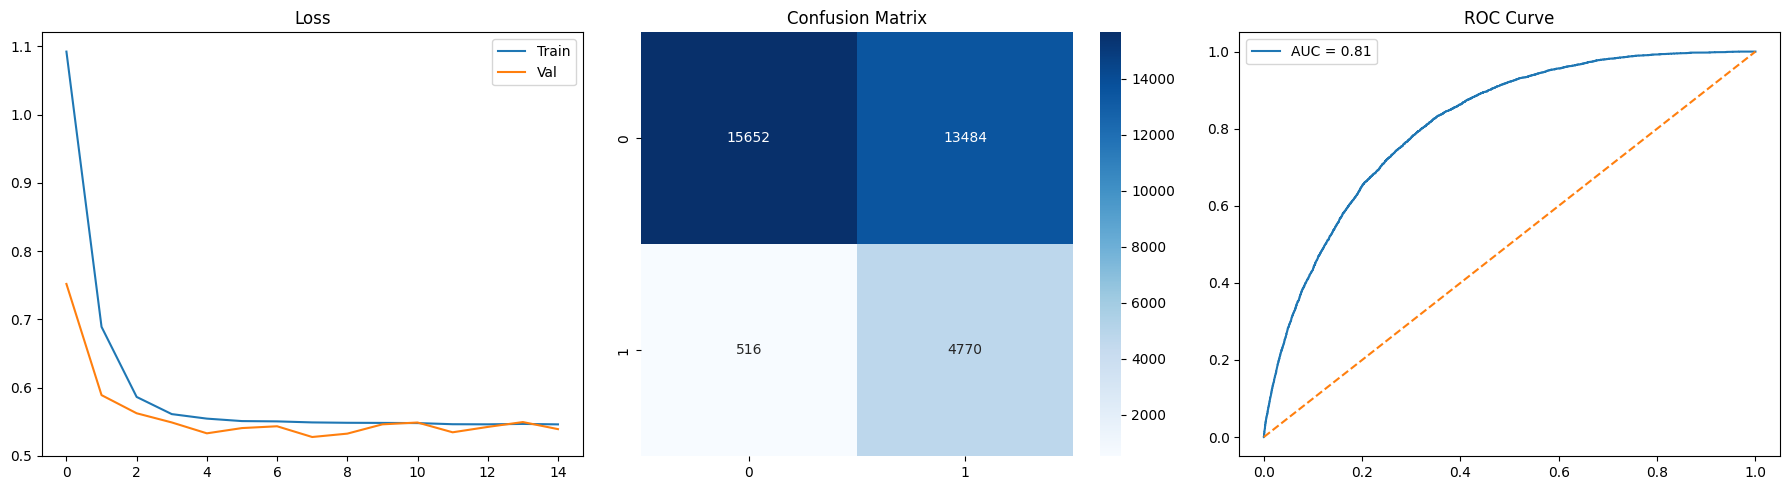


--- Rapport de classification ---
              precision    recall  f1-score   support

         0.0       0.97      0.54      0.69     29136
         1.0       0.26      0.90      0.41      5286

    accuracy                           0.59     34422
   macro avg       0.61      0.72      0.55     34422
weighted avg       0.86      0.59      0.65     34422



In [32]:
def build_model_optimise():

    model = Sequential()

    model.add(Input(shape=(X_train.shape[1],)))

    model.add(Dense(64, activation='relu', kernel_regularizer='l2'))
    model.add(BatchNormalization())
    model.add(Dropout(0.4))

    model.add(Dense(32, activation='relu', kernel_regularizer='l2'))
    model.add(BatchNormalization())
    model.add(Dropout(0.4))

    model.add(Dense(16, activation='relu'))
    model.add(Dropout(0.3))

    model.add(Dense(1, activation='sigmoid'))

    optimizer = Adam(learning_rate=0.0003)

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model



print("\n" + "="*60)
print("ENTRAÎNEMENT DU MODÈLE OPTIMISÉ")
print("="*60)

model_opt = build_model_optimise()

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True,
    verbose=1
)

tracker = EmissionsTracker(project_name="Modele_Diabete_Final", log_level="error")
tracker.start()

debut = time.time()

# 1. Activation de l'autolog Keras (sauvegarde le modèle, l'accuracy, la loss tout seul)
mlflow.keras.autolog()

# 2. Ouverture d'une session d'enregistrement MLflow
with mlflow.start_run(run_name="Sprint3_Optimisation_L2_Dropout"):

    # On précise notre seuil manuellement pour s'en souvenir
    mlflow.log_param("seuil_decision", 0.35)

    history_opt = model_opt.fit(
        X_train_scaled, y_train.to_numpy(), 
        epochs=80,
        batch_size=64,
        validation_data=(X_val_scaled, y_val.to_numpy()), 
        class_weight=class_weights,
        callbacks=[early_stop],
        verbose=0
    )

    emissions_kg = tracker.stop()
    energie_kwh = tracker.final_emissions_data.energy_consumed

    fin = time.time()
    temps_total = fin - debut

    epochs_reels = len(history_opt.history['loss'])
    economie_epochs = 80 - epochs_reels

    # 3. On enregistre nos métriques écologiques dans MLflow
    mlflow.log_metric("co2_grammes", emissions_kg * 1000)
    mlflow.log_metric("energie_kwh", energie_kwh)
    mlflow.log_metric("temps_entrainement_sec", temps_total)

    print("\n" + "="*60)
    print("BILAN ÉNERGÉTIQUE ET RAPIDITÉ :")
    print(f"⏱️ Temps d'entraînement total : {temps_total:.2f} secondes")
    print(f"📉 Epochs calculées : {epochs_reels} sur 80")
    print(f"🌱 Économie : {economie_epochs} epochs inutiles évitées !")
    print(f"⚡ Réduction d'environ {(economie_epochs/80)*100:.0f}% de la consommation prévue.")
    print(f"🔌 Consommation électrique mesurée : {energie_kwh:.6f} kWh")
    print(f"🌍 Émissions de CO2 estimées : {emissions_kg * 1000:.3f} grammes")
    print("="*60)


    y_pred_prob = model_opt.predict(X_test_scaled, verbose=0)
    y_pred = (y_pred_prob > 0.35).astype(int)



    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].plot(history_opt.history['loss'], label='Train')
    axes[0].plot(history_opt.history['val_loss'], label='Val')
    axes[0].set_title("Loss")
    axes[0].legend()

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1])
    axes[1].set_title("Confusion Matrix")

    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
    auc_score = auc(fpr, tpr)
    axes[2].plot(fpr, tpr, label=f"AUC = {auc(fpr,tpr):.2f}")
    axes[2].plot([0,1],[0,1],'--')
    axes[2].set_title("ROC Curve")
    axes[2].legend()
    
    mlflow.log_metric("auc_test", auc_score)
    mlflow.log_figure(fig, "graphiques_evaluation.png")
    plt.tight_layout()
    plt.show()



    print("\n--- Rapport de classification ---")
    print(classification_report(y_test, y_pred))




## Conclusion Sprint 2 & 3

Le modèle développé est un réseau de neurones dense construit avec TensorFlow/Keras, conçu pour un problème de classification binaire. Les données ont été standardisées à l’aide de StandardScaler, puis le modèle a été entraîné avec des techniques de régularisation (Dropout, L2, BatchNormalization) afin de limiter le surapprentissage. Un mécanisme d’Early Stopping a également été utilisé pour interrompre l’entraînement au moment optimal.

Après évaluation sur un jeu de test indépendant, les résultats montrent une bonne capacité de discrimination globale avec une AUC de 0.81. Cependant, l’analyse détaillée met en évidence un déséquilibre marqué dans les performances : la classe positive (diabète) est extrêmement bien détectée avec un rappel (Recall) très élevé de 0.90, tandis que sa précision reste faible (0.26). La classe négative (patients sains) est logiquement moins bien reconnue (rappel de 0.53). La matrice de confusion confirme cette tendance : le modèle a une forte propension à prédire la classe positive, générant ainsi un grand nombre de faux positifs.

En conclusion, si le modèle présente un déséquilibre mathématique, il se révèle extrêmement efficace pour son objectif premier : le dépistage de masse. Sur le plan clinique, nous avons fait le choix assumé de privilégier la sécurité des patients (maximisation du Recall) au détriment de la perfection mathématique. 

Ce biais volontaire est un compromis nécessaire : s'il engendre une précision plus faible, il nous permet en contrepartie une excellente détection des vrais malades (90 %). Dans un contexte de dépistage de santé publique, générer des examens de contrôle inutiles chez des patients sains reste infiniment préférable au risque dramatique de rater un diagnostic. Cette approche préventive stricte sécurise le parcours de soin et minimise drastiquement les cas manqués.